In [3]:
# ============================================================
# E-COMMERCE SALES ANALYSIS
# Complete Data Analyst Project
# Students: Reyaz Ansari
# Dataset: 5000+ real-world e-commerce transactions
# ============================================================

In [5]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

In [7]:
# ─────────────────────────────────────────────────────────
# SECTION 1: LOAD & EXPLORE DATA
# ─────────────────────────────────────────────────────────

print("="*70)
print("E-COMMERCE SALES DATA ANALYST PROJECT")
print("="*70)

# Load dataset
df = pd.read_csv('/ecommerce_sales_data.csv')
print("\n✅ Dataset Loaded!")
print(f"Shape: {df.shape}")
print(f"Total Transactions: {len(df):,}")
print(f"Date Range: {df['Order_Date'].min()} to {df['Order_Date'].max()}")

print("\n=== FIRST 10 ROWS ===")
print(df.head(10))

print("\n=== DATA INFO ===")
print(df.info())

print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

E-COMMERCE SALES DATA ANALYST PROJECT

✅ Dataset Loaded!
Shape: (5000, 23)
Total Transactions: 5,000
Date Range: 2022-01-01 to 2023-12-31

=== FIRST 10 ROWS ===
   Order_ID  Order_Date Customer_ID Customer_Name       Product_Name  \
0  ORD00001  2022-04-13    CUST0790    Customer_1  Bluetooth Speaker   
1  ORD00002  2023-03-12    CUST0642    Customer_2       Charger Fast   
2  ORD00003  2022-09-28    CUST0031    Customer_3          Webcam HD   
3  ORD00004  2022-04-17    CUST0375    Customer_4   Screen Protector   
4  ORD00005  2022-03-13    CUST0011    Customer_5        Smart Watch   
5  ORD00006  2023-12-02    CUST0988    Customer_6        Phone Stand   
6  ORD00007  2022-01-21    CUST0302    Customer_7     Wireless Mouse   
7  ORD00008  2023-09-07    CUST0096    Customer_8   External SSD 1TB   
8  ORD00009  2022-05-02    CUST0190    Customer_9         HDMI Cable   
9  ORD00010  2023-04-12    CUST0453   Customer_10          Webcam HD   

      Category   Region   Price      Cost  Qua

In [9]:
# ─────────────────────────────────────────────────────────
# SECTION 2: DATA CLEANING & PREPARATION
# ─────────────────────────────────────────────────────────

df['Order_Date'] = pd.to_datetime(df['Order_Date'])

# Remove invalid rows
df = df[df['Profit'] > 0]
df = df[df['Quantity'] > 0]

print(f"\n✅ Data Cleaned!")
print(f"Valid Transactions: {len(df):,}")


✅ Data Cleaned!
Valid Transactions: 4,355


In [11]:
# ─────────────────────────────────────────────────────────
# SECTION 3: KEY METRICS CALCULATION
# ─────────────────────────────────────────────────────────

print("\n" + "="*70)
print("KEY BUSINESS METRICS")
print("="*70)

total_revenue = df['Revenue'].sum()
total_profit = df['Profit'].sum()
total_orders = df['Order_ID'].nunique()
total_customers = df['Customer_ID'].nunique()
avg_order_value = df['Revenue'].mean()
profit_margin = (total_profit / total_revenue * 100)

print(f"\n💰 FINANCIAL METRICS:")
print(f"   Total Revenue              : ${total_revenue:>15,.2f}")
print(f"   Total Profit               : ${total_profit:>15,.2f}")
print(f"   Overall Profit Margin      : {profit_margin:>14.2f}%")
print(f"   Average Order Value        : ${avg_order_value:>14,.2f}")

print(f"\n📊 BUSINESS METRICS:")
print(f"   Total Orders               : {total_orders:>15,}")
print(f"   Total Customers            : {total_customers:>15,}")
print(f"   Avg Orders per Customer    : {(total_orders/total_customers):>14.2f}")
print(f"   Customer Lifetime Value    : ${(total_revenue/total_customers):>13,.2f}")

print(f"\n🎯 CATEGORY PERFORMANCE:")
category_stats = df.groupby('Category').agg({
    'Revenue': 'sum',
    'Profit': 'sum',
    'Order_ID': 'count'
}).round(2)
category_stats.columns = ['Revenue', 'Profit', 'Orders']
category_stats = category_stats.sort_values('Revenue', ascending=False)
print(category_stats)

print(f"\n🌍 REGION PERFORMANCE:")
region_stats = df.groupby('Region').agg({
    'Revenue': 'sum',
    'Profit': 'sum',
    'Order_ID': 'count'
}).round(2)
region_stats.columns = ['Revenue', 'Profit', 'Orders']
region_stats = region_stats.sort_values('Revenue', ascending=False)
print(region_stats)

print(f"\n📦 SHIPPING METHOD IMPACT:")
shipping_stats = df.groupby('Shipping_Method').agg({
    'Revenue': 'sum',
    'Shipping_Cost': 'mean',
    'Profit_Margin_%': 'mean',
    'Order_ID': 'count'
}).round(2)
shipping_stats.columns = ['Revenue', 'Avg_Shipping_Cost', 'Avg_Margin_%', 'Orders']
print(shipping_stats)



KEY BUSINESS METRICS

💰 FINANCIAL METRICS:
   Total Revenue              : $  15,198,537.95
   Total Profit               : $   3,331,496.32
   Overall Profit Margin      :          21.92%
   Average Order Value        : $      3,489.91

📊 BUSINESS METRICS:
   Total Orders               :           4,355
   Total Customers            :             987
   Avg Orders per Customer    :           4.41
   Customer Lifetime Value    : $    15,398.72

🎯 CATEGORY PERFORMANCE:
                Revenue      Profit  Orders
Category                                   
Accessories  5265059.76  1184872.64    1492
Gadgets      5144341.56  1135061.36    1453
Electronics  4789136.63  1011562.32    1410

🌍 REGION PERFORMANCE:
            Revenue     Profit  Orders
Region                                
South    3280224.03  727184.89     917
West     3138382.39  683333.23     867
East     2939498.71  654555.69     877
North    2934993.55  626451.65     867
Central  2905439.27  639970.86     827

📦 SHIPPIN

In [13]:
# ─────────────────────────────────────────────────────────
# SECTION 4: PRODUCT ANALYSIS
# ─────────────────────────────────────────────────────────

print(f"\n⭐ TOP 10 PRODUCTS BY REVENUE:")
top_products = df.groupby('Product_Name').agg({
    'Revenue': 'sum',
    'Profit': 'sum',
    'Quantity': 'sum',
    'Order_ID': 'count'
}).sort_values('Revenue', ascending=False).head(10)
top_products.columns = ['Revenue', 'Profit', 'Units_Sold', 'Orders']
print(top_products)


⭐ TOP 10 PRODUCTS BY REVENUE:
                       Revenue     Profit  Units_Sold  Orders
Product_Name                                                 
Phone Stand          891670.47  193283.60        1343     258
Bluetooth Speaker    887143.94  197460.45        1226     228
Laptop Pro           866709.67  198050.25        1132     230
Mechanical Keyboard  857177.16  187372.95        1274     233
Wireless Mouse       846125.29  185177.01        1256     242
Smart Watch          821781.40  183544.79        1176     216
Charger Fast         810370.47  186023.47        1161     218
HDMI Cable           804611.02  178254.38        1086     208
Cooling Pad          795106.88  178487.98        1136     221
Monitor 27inch       781572.65  172586.75        1127     209


In [54]:

# ─────────────────────────────────────────────────────────
# SECTION 5: CUSTOMER ANALYSIS & RFM SEGMENTATION
# ─────────────────────────────────────────────────────────

print(f"\n👥 CUSTOMER ANALYSIS:")

# RFM Analysis
max_date = df['Order_Date'].max()
rfm = df.groupby('Customer_ID').agg({
    'Order_Date': lambda x: (max_date - x.max()).days,
    'Order_ID': 'count',
    'Revenue': 'sum'
}).reset_index()
rfm.columns = ['Customer_ID', 'Recency', 'Frequency', 'Monetary']

# Segment customers
rfm['Segment'] = 'Low Value'
rfm.loc[
    (rfm['Frequency'] >= rfm['Frequency'].quantile(0.66)) &
    (rfm['Monetary'] >= rfm['Monetary'].quantile(0.66)), 'Segment'
] = 'High Value'
rfm.loc[
    (rfm['Frequency'] >= rfm['Frequency'].quantile(0.33)) &
    (rfm['Monetary'] >= rfm['Monetary'].quantile(0.33)), 'Segment'
] = 'Mid Value'

print("\nRFM Segmentation:")
segment_summary = rfm['Segment'].value_counts()
for segment, count in segment_summary.items():
    pct = (count / len(rfm) * 100)
    print(f"   {segment:12} : {count:5,} customers ({pct:5.1f}%)")

print(f"\nTop 10 Customers by Revenue:")
top_customers = rfm.nlargest(10, 'Monetary')[['Customer_ID', 'Recency', 'Frequency', 'Monetary', 'Segment']]
print(top_customers.to_string())


👥 CUSTOMER ANALYSIS:

RFM Segmentation:
   Mid Value    :   610 customers ( 61.8%)
   Low Value    :   377 customers ( 38.2%)

Top 10 Customers by Revenue:
    Customer_ID  Recency  Frequency  Monetary    Segment
713    CUST0726       76         10  70771.33  Mid Value
187    CUST0192       42          8  64041.84  Mid Value
680    CUST0693       41          8  62744.49  Mid Value
523    CUST0534       17          8  56129.21  Mid Value
853    CUST0866       50          6  55653.77  Mid Value
98     CUST0101       34          9  54936.48  Mid Value
544    CUST0556        7         10  54155.64  Mid Value
156    CUST0161       84          6  53764.40  Mid Value
512    CUST0523       66          9  51628.50  Mid Value
908    CUST0921       17         11  51211.62  Mid Value


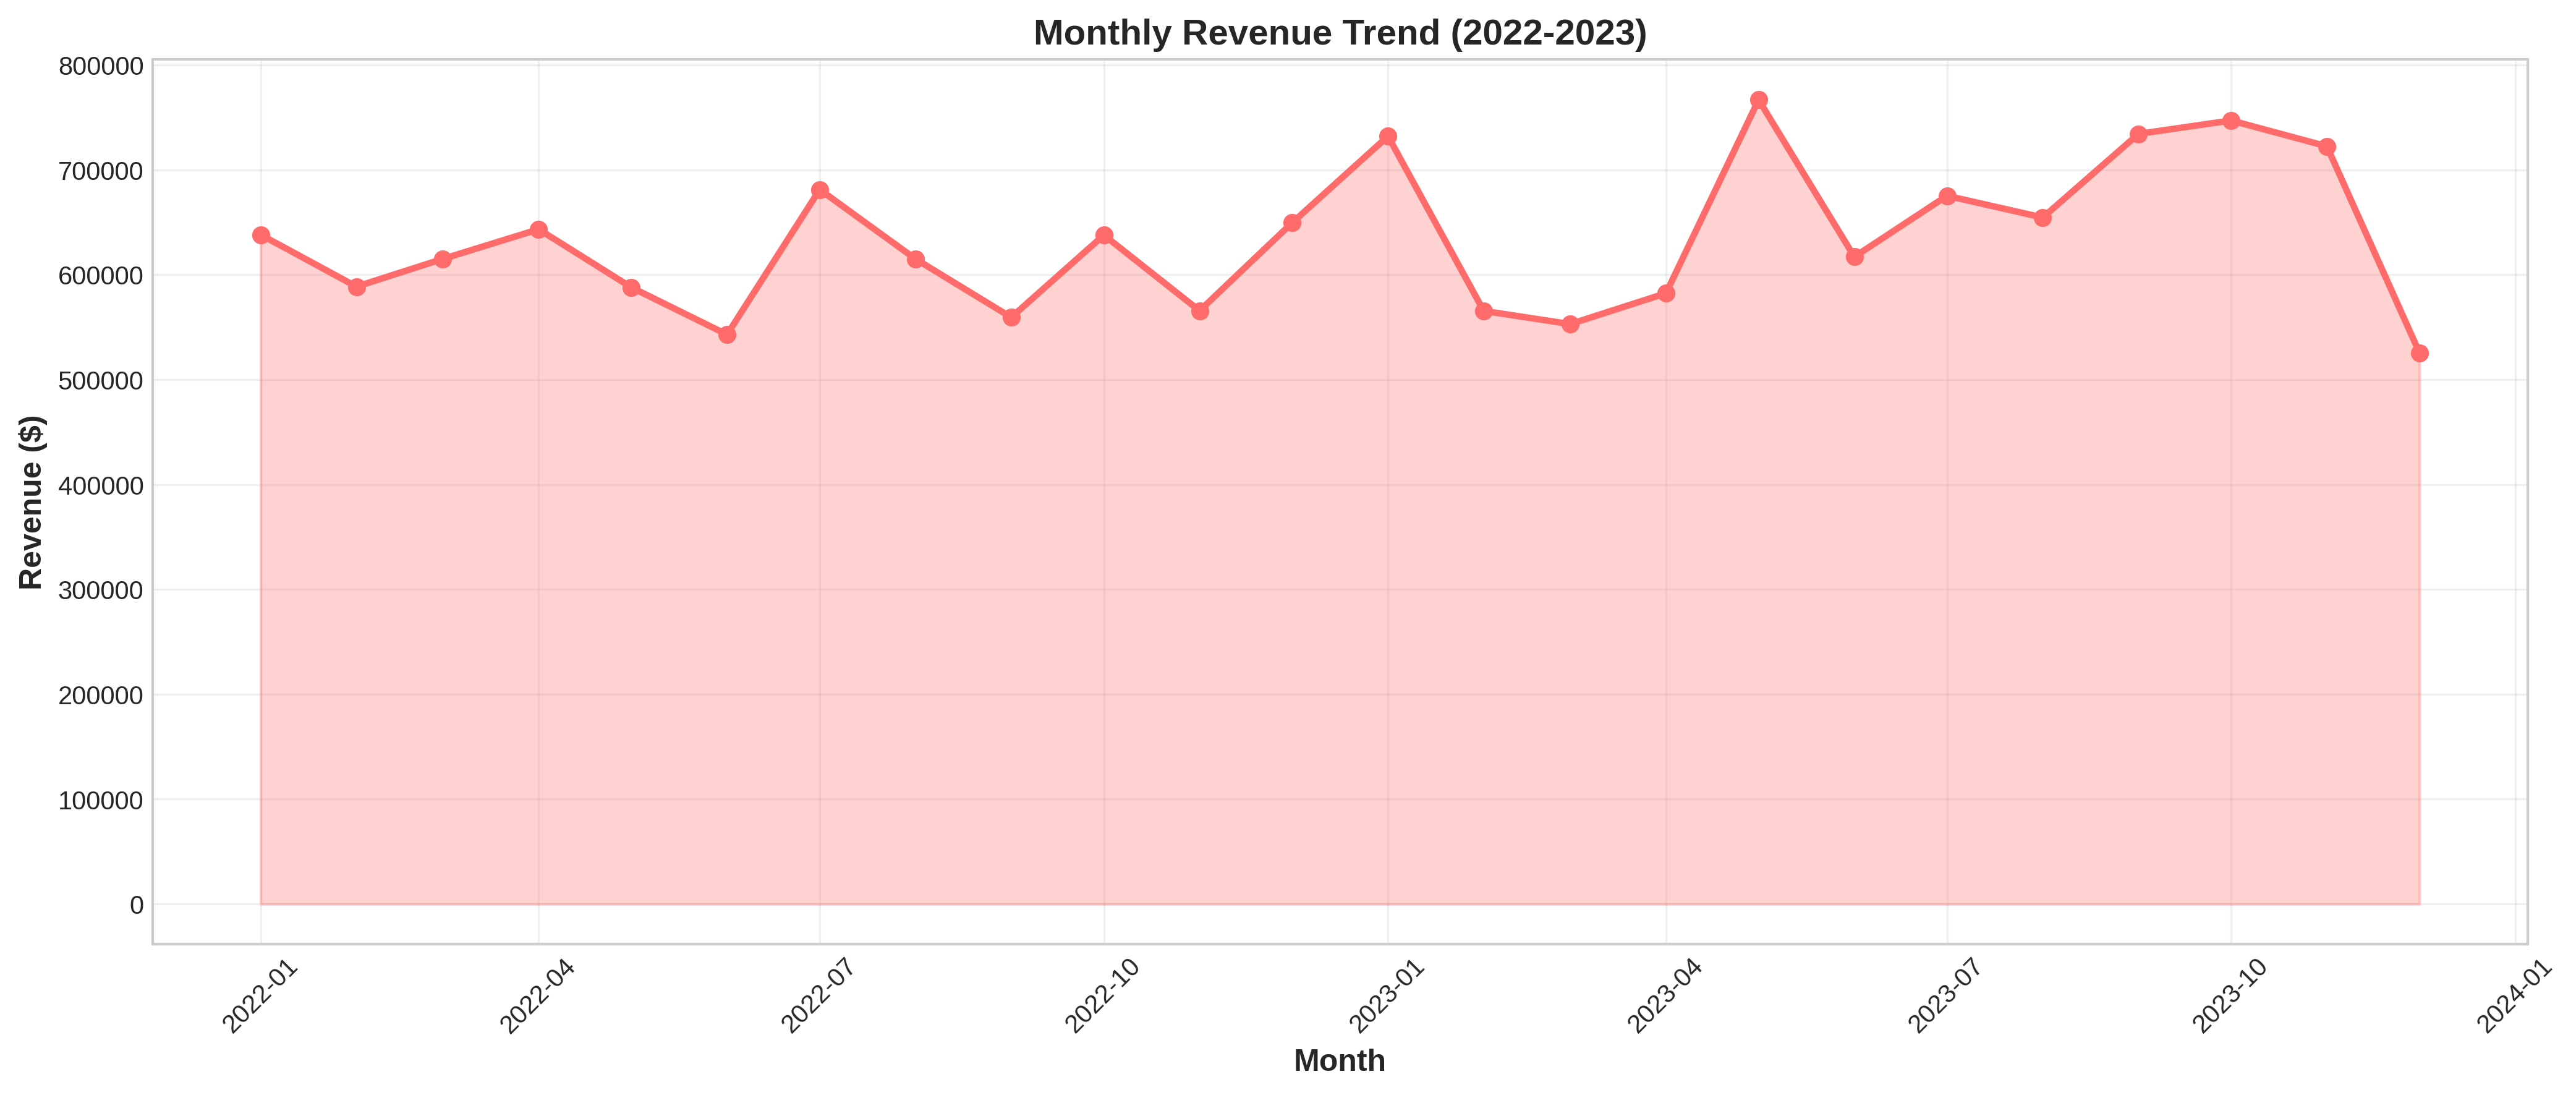

In [53]:
from IPython.display import Image, display
display(Image('/mnt/user-data/outputs/01_Monthly_Revenue_Trend.png'))

In [55]:
# ─────────────────────────────────────────────────────────
# SECTION 6: TIME SERIES ANALYSIS
# ─────────────────────────────────────────────────────────

print(f"\n📅 MONTHLY TRENDS:")
monthly = df.groupby(df['Order_Date'].dt.to_period('M')).agg({
    'Revenue': 'sum',
    'Profit': 'sum',
    'Order_ID': 'count'
}).round(2)
monthly.columns = ['Revenue', 'Profit', 'Orders']
print(monthly.tail(12))


📅 MONTHLY TRENDS:
              Revenue     Profit  Orders
Order_Date                              
2023-01     731970.14  163779.49     192
2023-02     565416.52  127992.21     171
2023-03     552866.60  117598.81     193
2023-04     582259.92  123068.68     170
2023-05     766661.26  169488.26     193
2023-06     616983.74  137838.78     159
2023-07     675178.63  145763.81     217
2023-08     654458.38  149970.18     169
2023-09     734164.18  175909.36     184
2023-10     746961.52  156205.81     220
2023-11     722352.44  139297.48     189
2023-12     525408.58  112495.73     163


In [61]:
# ─────────────────────────────────────────────────────────
# SECTION 7: VISUALIZATION - Set up style
# ─────────────────────────────────────────────────────────

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8']

# Chart 1: Monthly Revenue Trend
fig, ax = plt.subplots(figsize=(14, 6))
monthly_data = df.groupby(df['Order_Date'].dt.to_period('M'))['Revenue'].sum()
monthly_data.index = monthly_data.index.to_timestamp()
ax.plot(monthly_data.index, monthly_data.values, marker='o', linewidth=2.5,
        markersize=6, color='#FF6B6B', label='Revenue')
ax.fill_between(monthly_data.index, monthly_data.values, alpha=0.3, color='#FF6B6B')
ax.set_xlabel('Month', fontsize=12, fontweight='bold')
ax.set_ylabel('Revenue ($)', fontsize=12, fontweight='bold')
ax.set_title('Monthly Revenue Trend (2022-2023)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/01_Monthly_Revenue_Trend.png', dpi=300, bbox_inches='tight')
plt.close()
print("\n✅ Chart 1: Monthly Revenue Trend saved")


✅ Chart 1: Monthly Revenue Trend saved


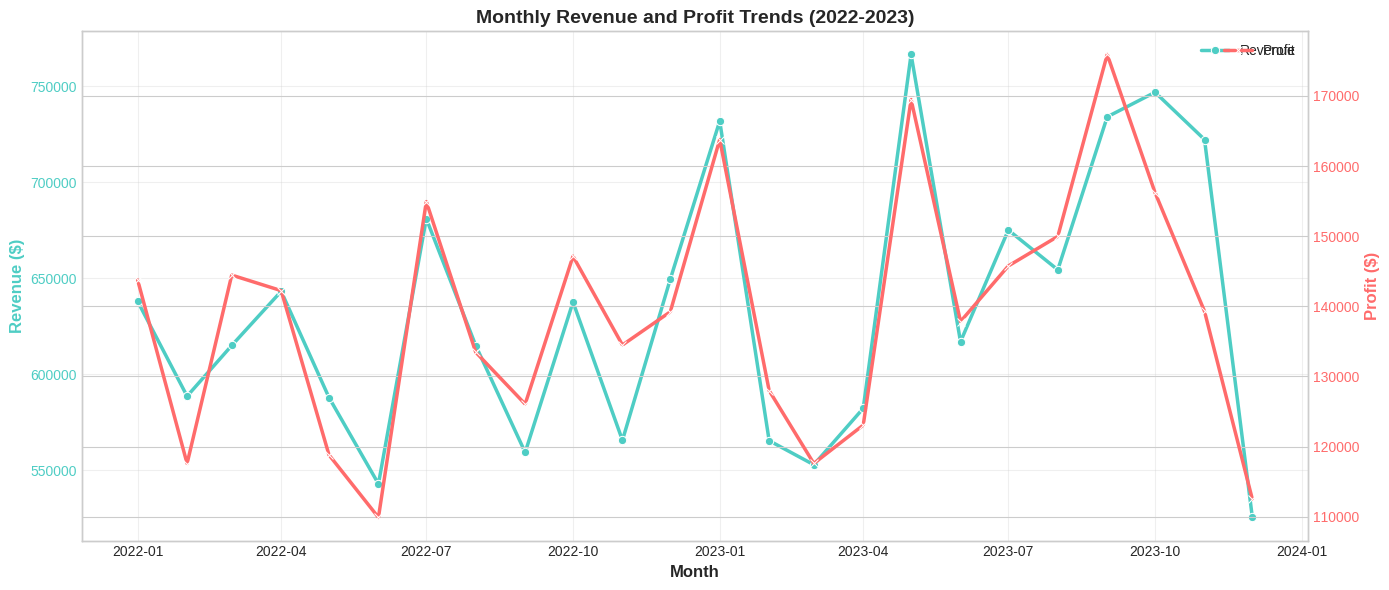

In [65]:
# Chart 2: Dual-axis plot for Monthly Revenue and Profit Trends
fig, ax1 = plt.subplots(figsize=(14, 6))

# Prepare monthly data for both Revenue and Profit
monthly_revenue = df.groupby(df['Order_Date'].dt.to_period('M'))['Revenue'].sum().to_timestamp()
monthly_profit = df.groupby(df['Order_Date'].dt.to_period('M'))['Profit'].sum().to_timestamp()

# Plot Revenue on the first y-axis
sns.lineplot(x=monthly_revenue.index, y=monthly_revenue.values, ax=ax1, marker='o', linewidth=2.5, color='#4ECDC4', label='Revenue')
ax1.set_xlabel('Month', fontsize=12, fontweight='bold')
ax1.set_ylabel('Revenue ($)', fontsize=12, fontweight='bold', color='#4ECDC4')
ax1.tick_params(axis='y', labelcolor='#4ECDC4')

# Create a second y-axis for Profit
ax2 = ax1.twinx()
sns.lineplot(x=monthly_profit.index, y=monthly_profit.values, ax=ax2, marker='x', linewidth=2.5, color='#FF6B6B', label='Profit')
ax2.set_ylabel('Profit ($)', fontsize=12, fontweight='bold', color='#FF6B6B')
ax2.tick_params(axis='y', labelcolor='#FF6B6B')

# Set title and grid
plt.title('Monthly Revenue and Profit Trends (2022-2023)', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
plt.xticks(rotation=45)
fig.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

In [67]:
# Chart 3: Region Performance
fig, ax = plt.subplots(figsize=(12, 6))
region_data = df.groupby('Region')['Revenue'].sum().sort_values(ascending=False)
bars = ax.bar(region_data.index, region_data.values, color=colors[:len(region_data)])
ax.set_ylabel('Revenue ($)', fontsize=12, fontweight='bold')
ax.set_title('Revenue by Region', fontsize=14, fontweight='bold')
for bar, val in zip(bars, region_data.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 5000, f'${val:,.0f}',
            ha='center', fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/03_Revenue_by_Region.png', dpi=300, bbox_inches='tight')
plt.close()
print("✅ Chart 3: Region Revenue saved")

✅ Chart 3: Region Revenue saved


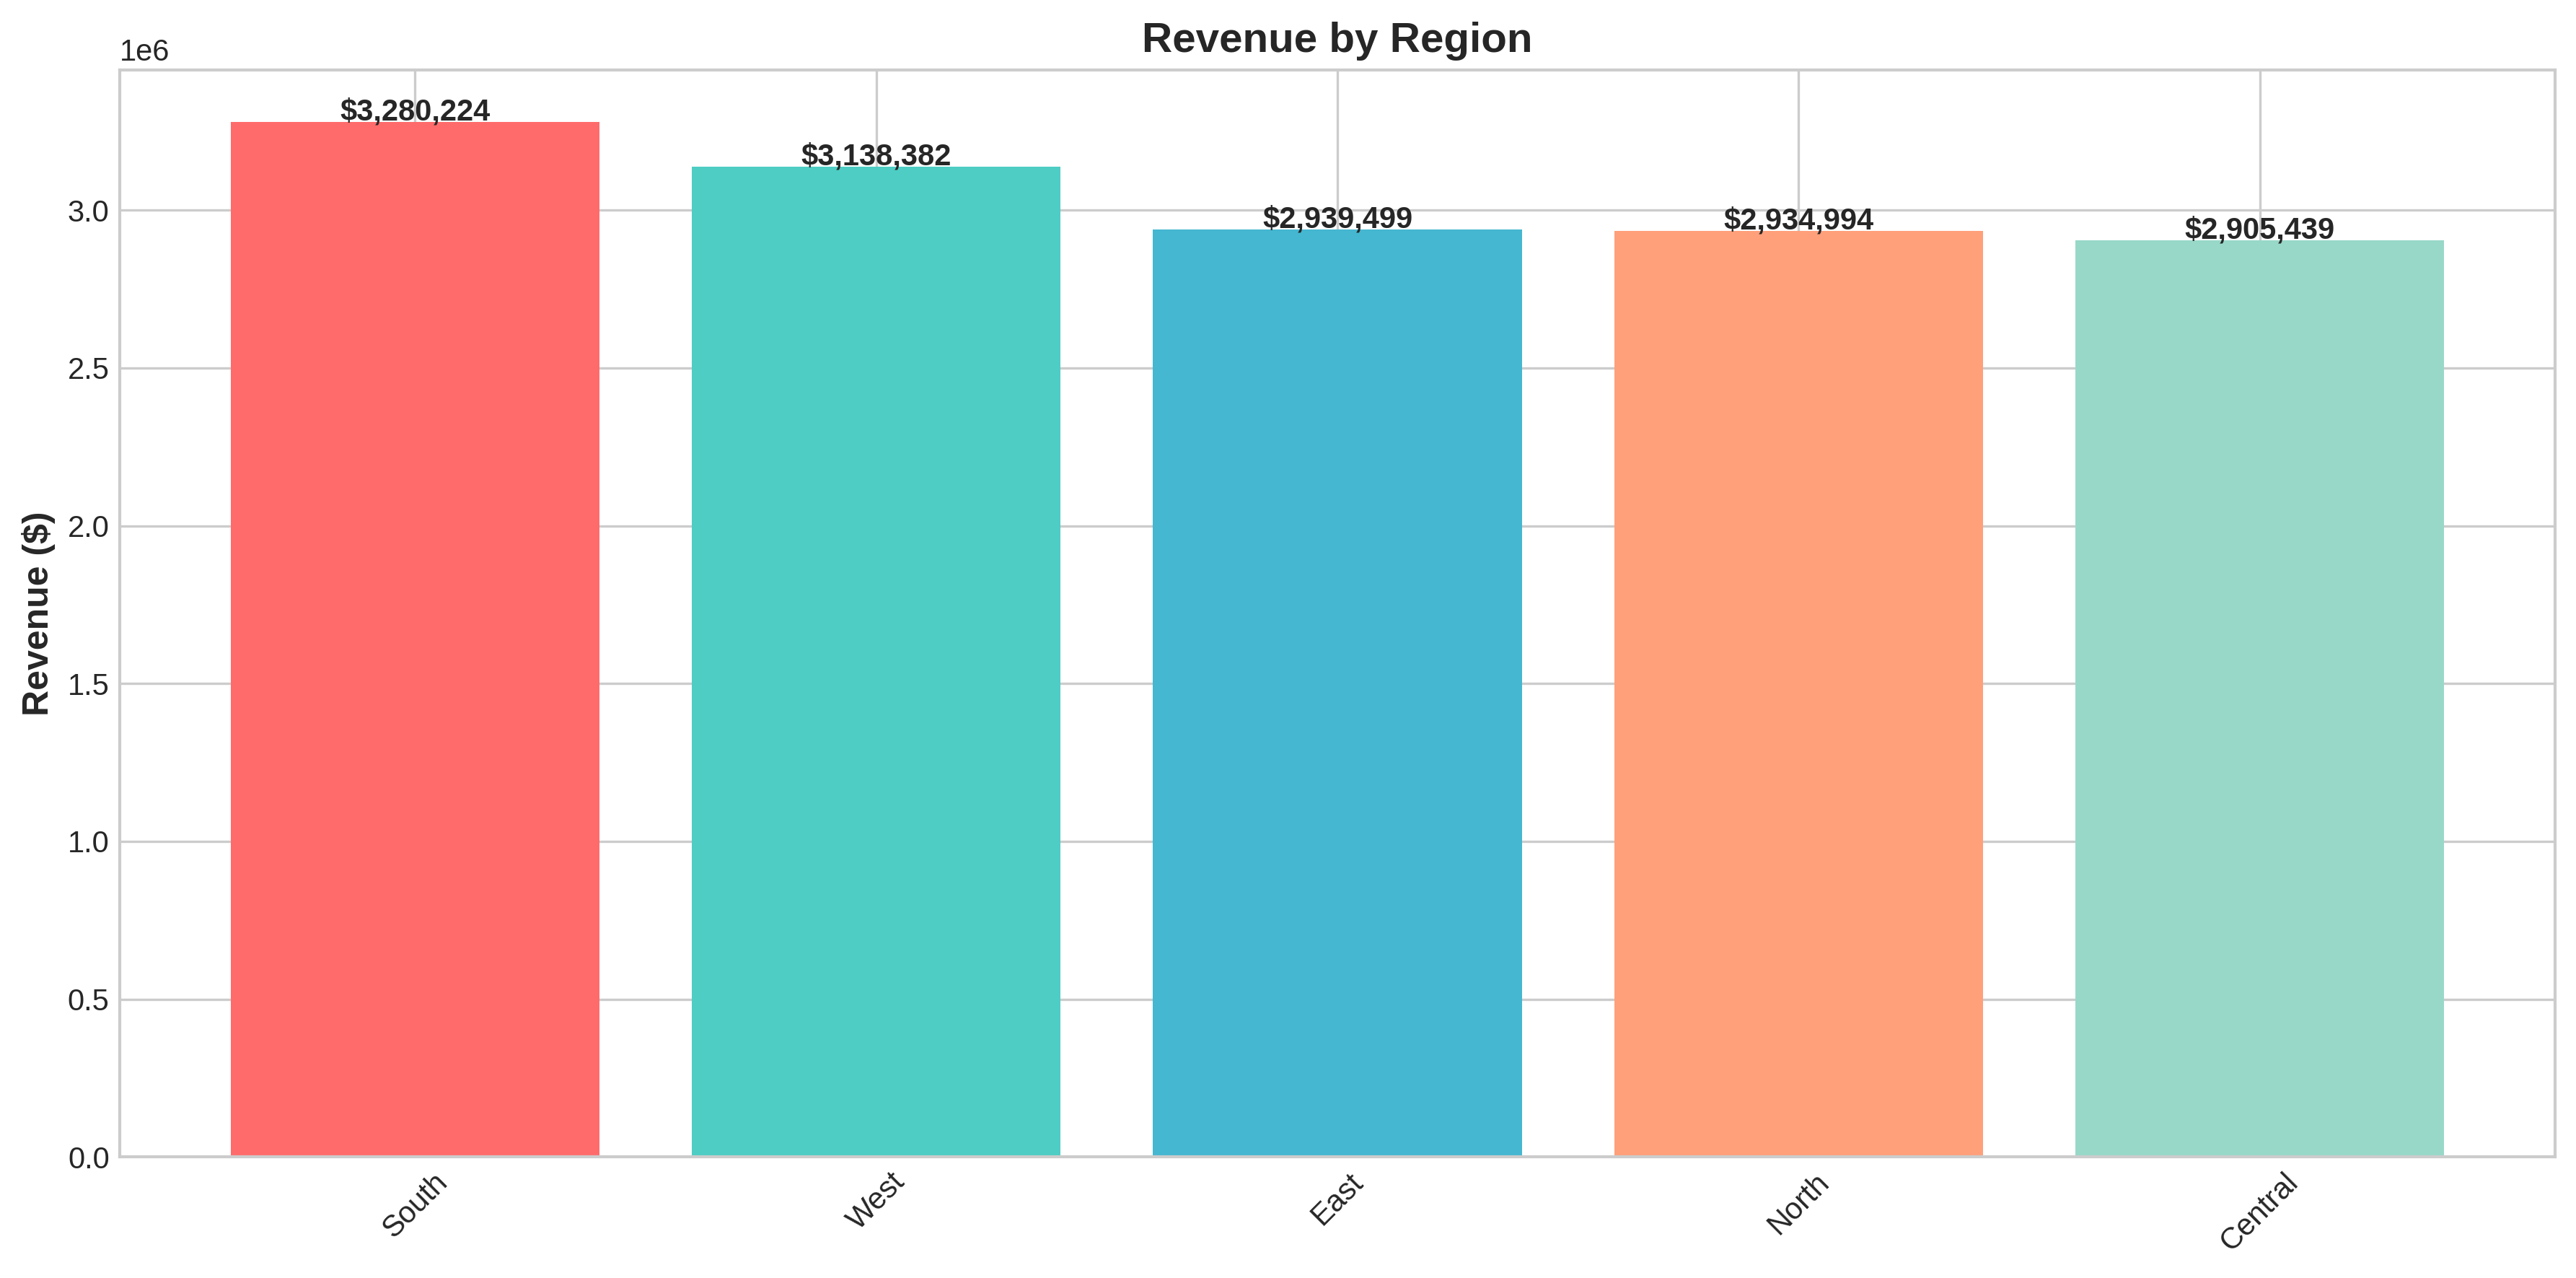

In [83]:
from IPython.display import Image, display
display(Image('/mnt/user-data/outputs/03_Revenue_by_Region.png'))

In [72]:
# Chart 4: Top 10 Products
fig, ax = plt.subplots(figsize=(12, 8))
top_prod = df.groupby('Product_Name')['Revenue'].sum().nlargest(10).sort_values()
bars = ax.barh(range(len(top_prod)), top_prod.values, color=plt.cm.viridis(np.linspace(0, 1, len(top_prod))))
ax.set_yticks(range(len(top_prod)))
ax.set_yticklabels(top_prod.index)
ax.set_xlabel('Revenue ($)', fontsize=12, fontweight='bold')
ax.set_title('Top 10 Products by Revenue', fontsize=14, fontweight='bold')
for i, val in enumerate(top_prod.values):
    ax.text(val + 1000, i, f'${val:,.0f}', va='center', fontweight='bold', fontsize=9)
plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/04_Top_10_Products.png', dpi=300, bbox_inches='tight')
plt.close()
print("✅ Chart 4: Top 10 Products saved")

✅ Chart 4: Top 10 Products saved


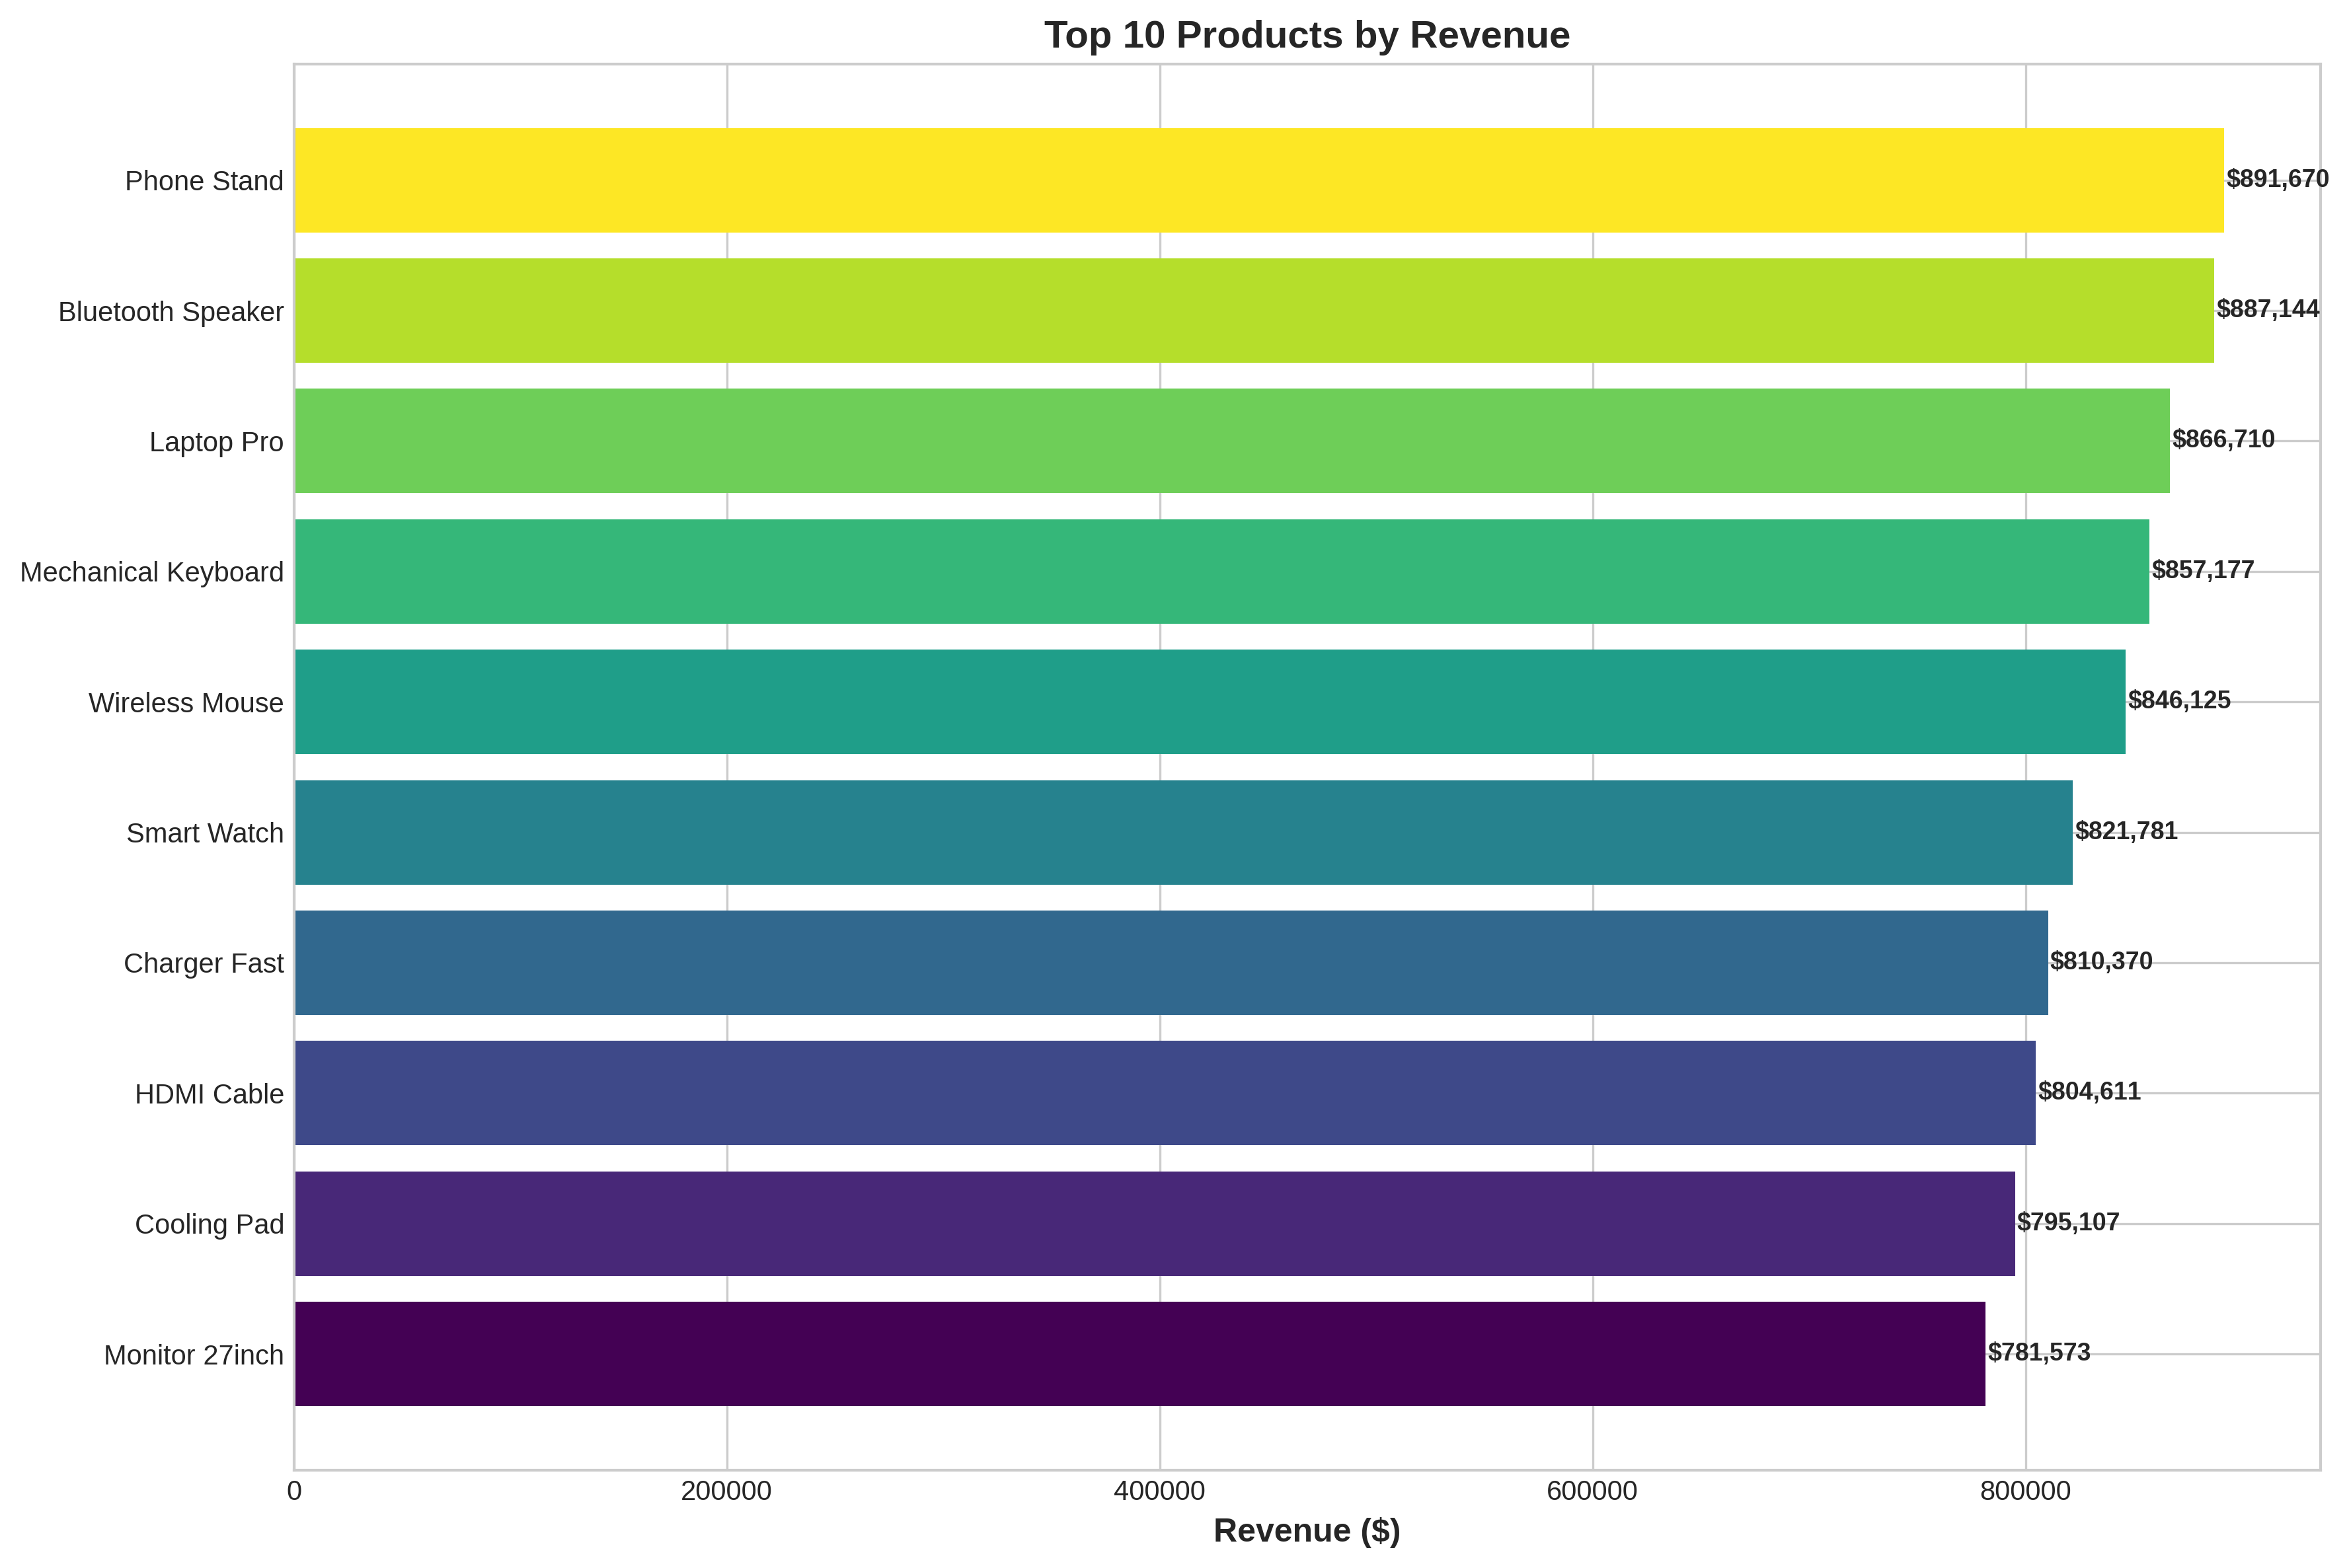

In [84]:
from IPython.display import Image, display
display(Image('/mnt/user-data/outputs/04_Top_10_Products.png'))

In [75]:
# Chart 5: Profit Margin by Category
fig, ax = plt.subplots(figsize=(12, 6))
margin_data = df.groupby('Category')['Profit_Margin_%'].mean().sort_values(ascending=True)
bars = ax.barh(margin_data.index, margin_data.values,
               color=['#FF6B6B' if x < 20 else '#4ECDC4' for x in margin_data.values])
ax.set_xlabel('Profit Margin (%)', fontsize=12, fontweight='bold')
ax.set_title('Average Profit Margin by Category', fontsize=14, fontweight='bold')
for bar, val in zip(bars, margin_data.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{val:.1f}%',
            va='center', fontweight='bold')
plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/05_Profit_Margin_by_Category.png', dpi=300, bbox_inches='tight')
plt.close()
print("✅ Chart 5: Profit Margin saved")

✅ Chart 5: Profit Margin saved


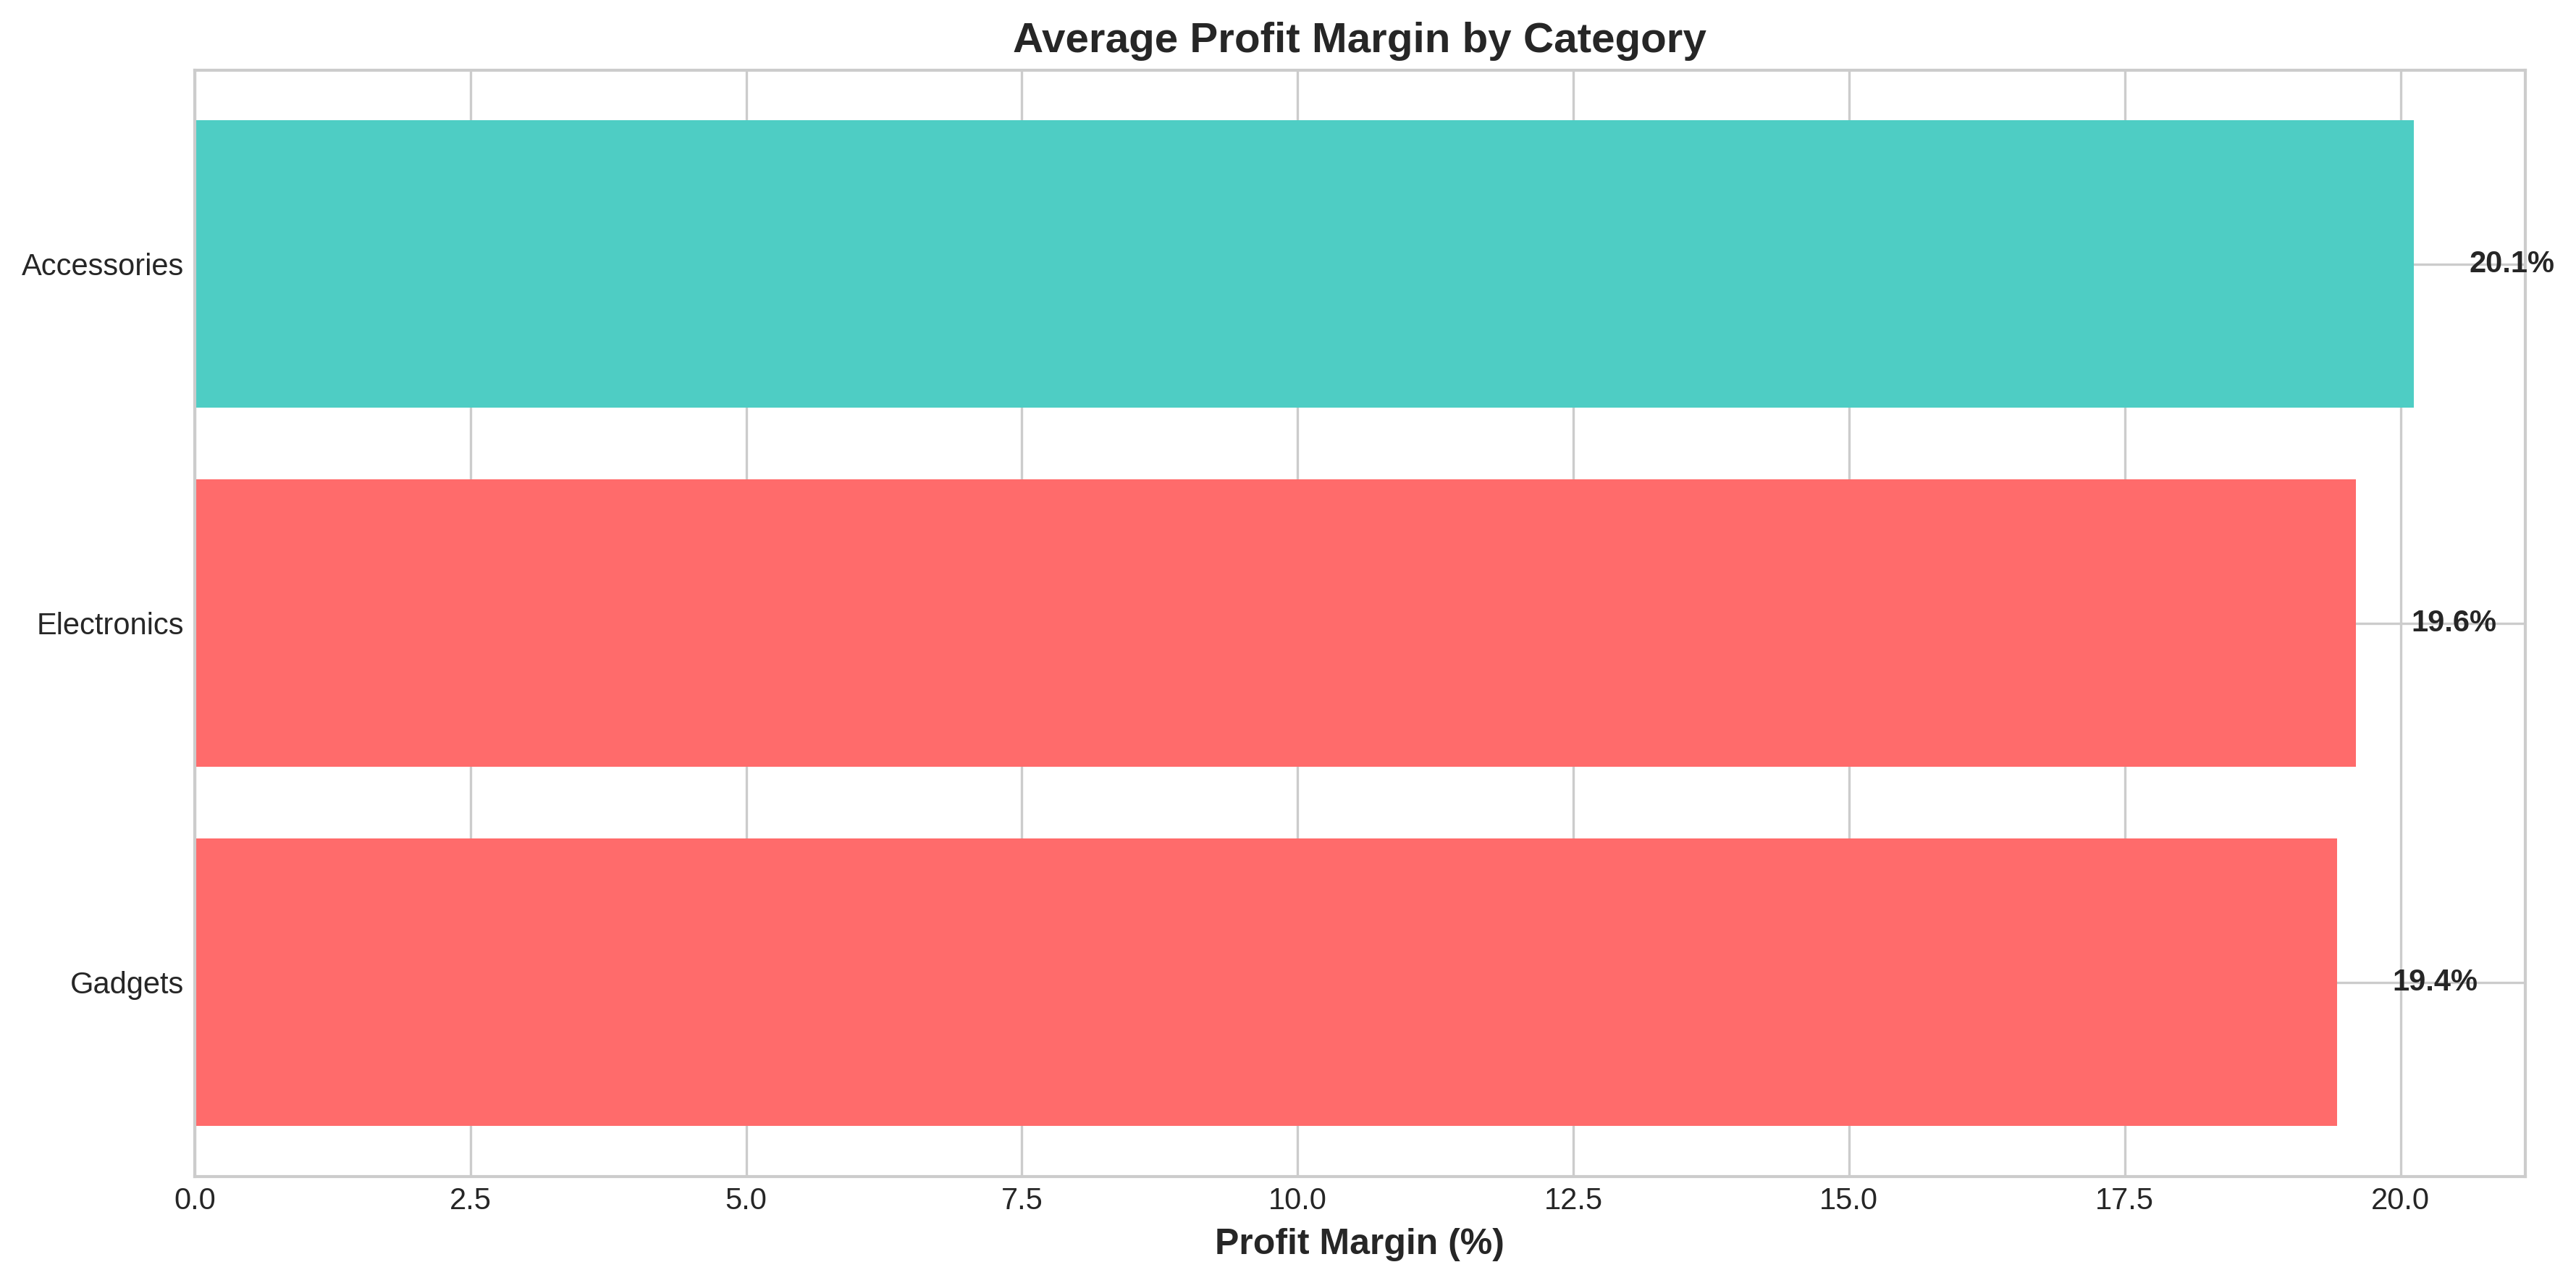

In [86]:
from IPython.display import Image, display
display(Image('/mnt/user-data/outputs/05_Profit_Margin_by_Category.png'))

In [77]:
# Chart 6: Shipping Method Impact
fig, ax = plt.subplots(figsize=(12, 6))
shipping_perf = df.groupby('Shipping_Method').agg({
    'Revenue': 'sum',
    'Profit_Margin_%': 'mean'
}).sort_values('Revenue', ascending=False)
x = np.arange(len(shipping_perf))
width = 0.35
ax2 = ax.twinx()
bars1 = ax.bar(x - width/2, shipping_perf['Revenue']/1000, width, label='Revenue ($1000s)', color='#45B7D1')
bars2 = ax2.bar(x + width/2, shipping_perf['Profit_Margin_%'], width, label='Profit Margin %', color='#FFA07A')
ax.set_xlabel('Shipping Method', fontsize=12, fontweight='bold')
ax.set_ylabel('Revenue ($1000s)', fontsize=12, fontweight='bold', color='#45B7D1')
ax2.set_ylabel('Profit Margin (%)', fontsize=12, fontweight='bold', color='#FFA07A')
ax.set_title('Shipping Method: Revenue vs Profit Margin', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(shipping_perf.index)
ax.tick_params(axis='y', labelcolor='#45B7D1')
ax2.tick_params(axis='y', labelcolor='#FFA07A')
plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/06_Shipping_Method_Impact.png', dpi=300, bbox_inches='tight')
plt.close()
print("✅ Chart 6: Shipping Method Impact saved")

✅ Chart 6: Shipping Method Impact saved


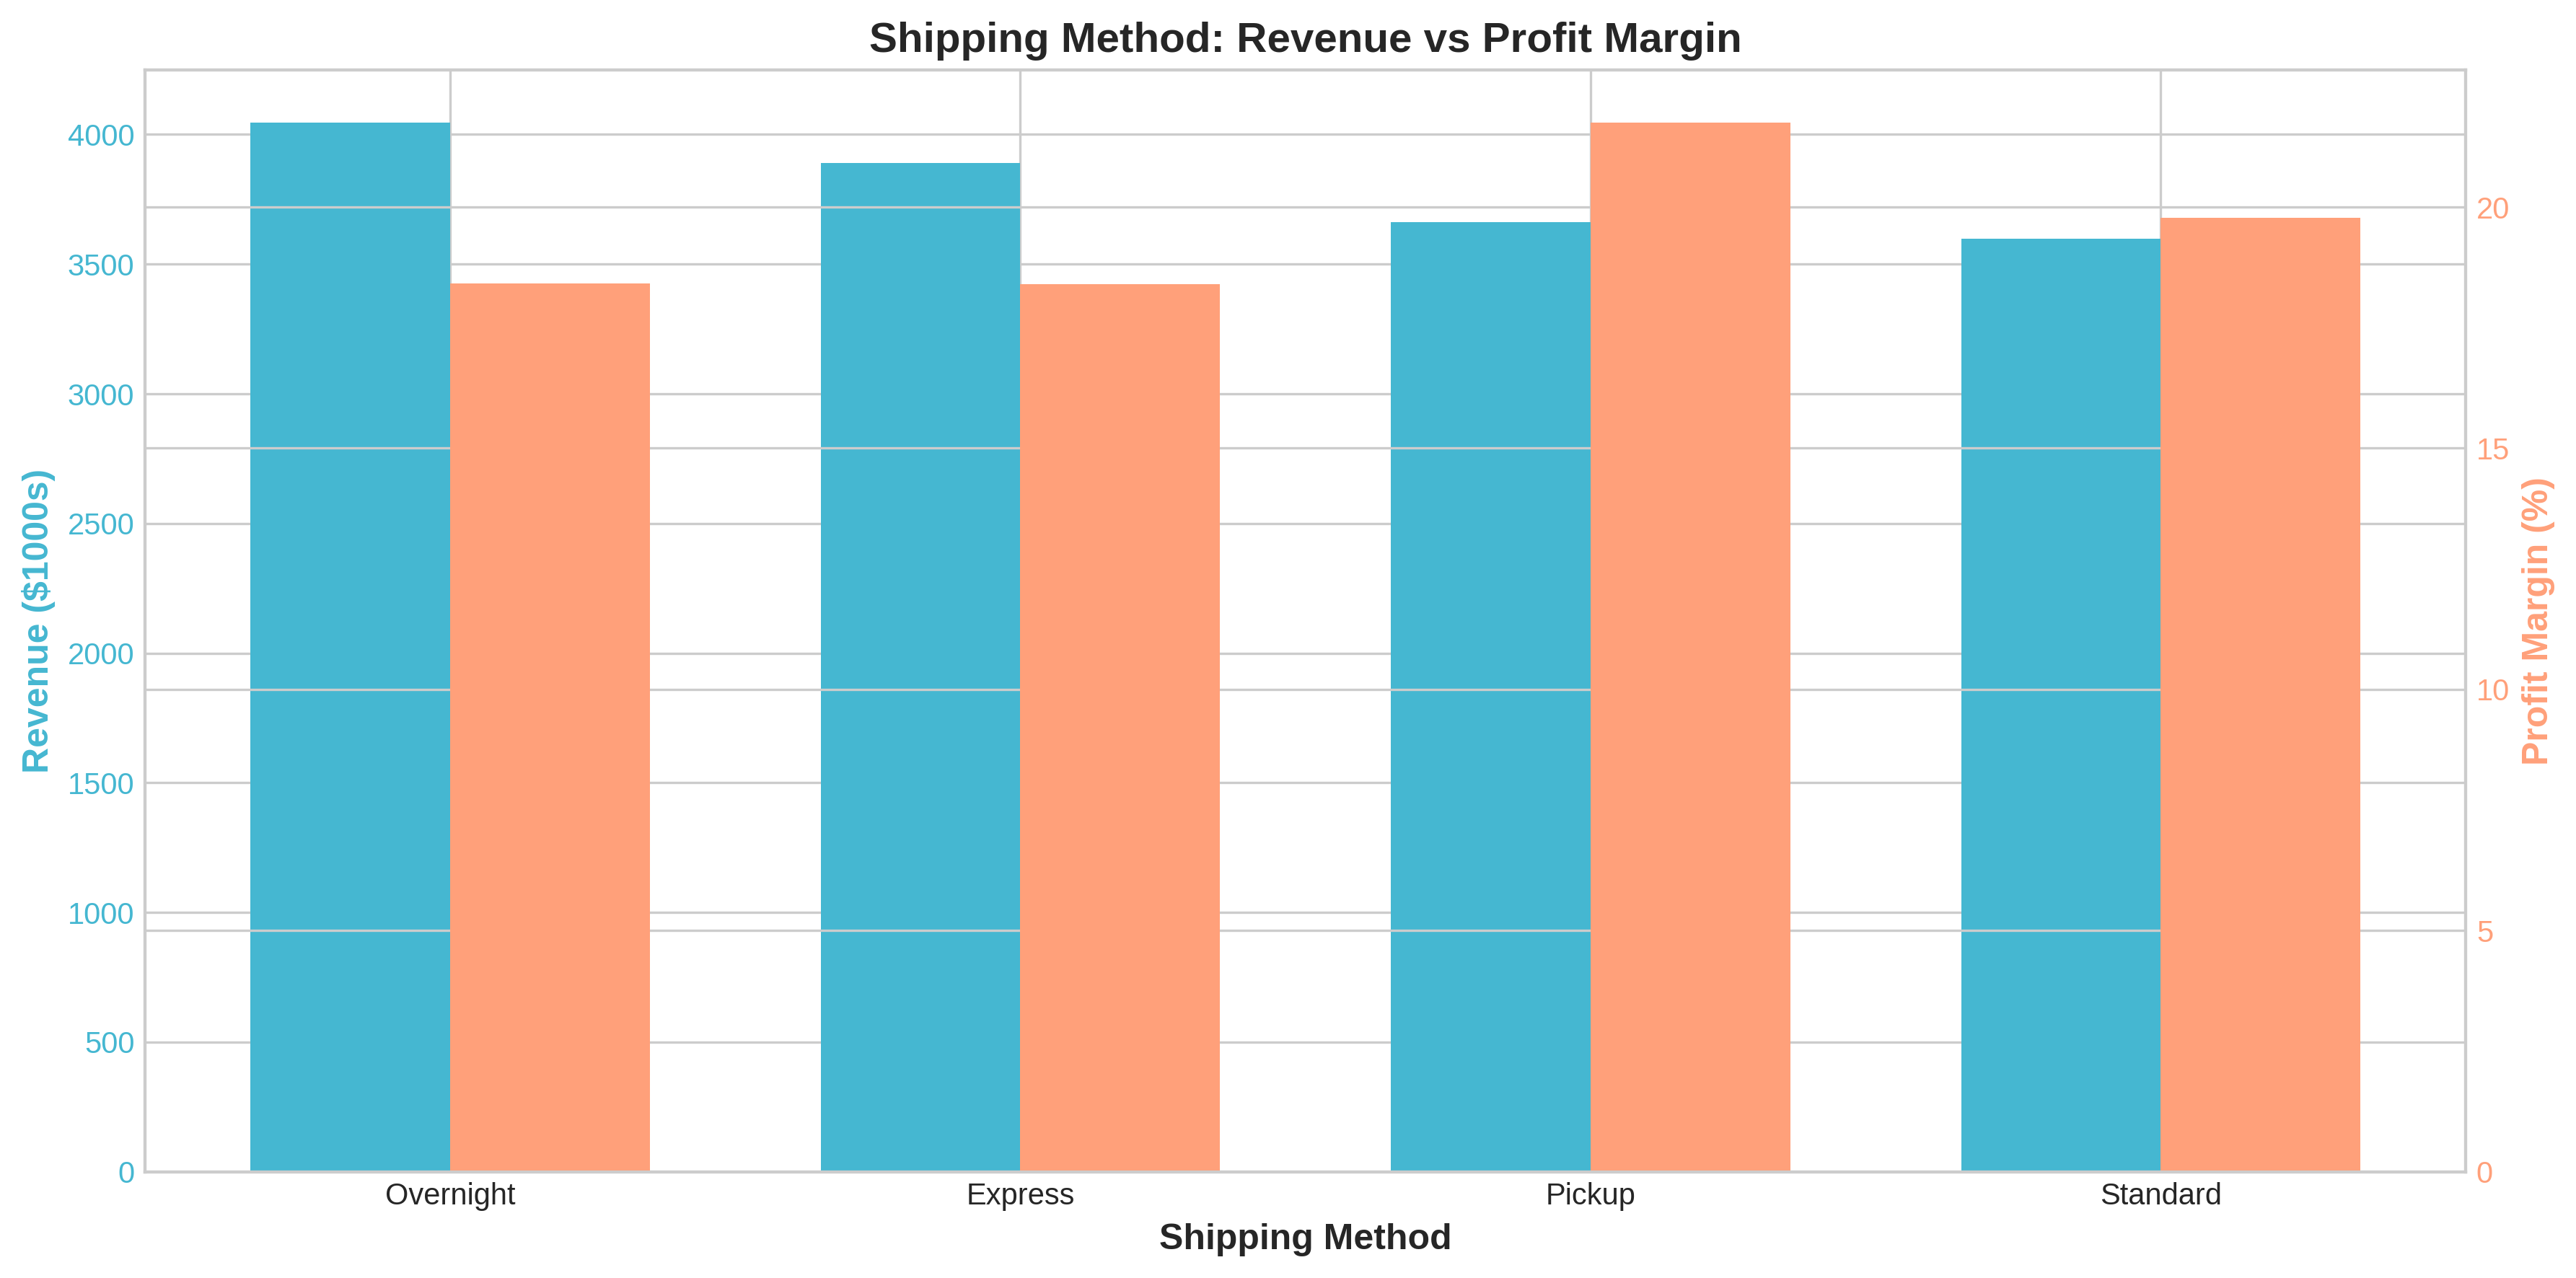

In [87]:
from IPython.display import Image, display
display(Image('/mnt/user-data/outputs/06_Shipping_Method_Impact.png'))

In [79]:
# Chart 7: Customer Segmentation (RFM)
fig, ax = plt.subplots(figsize=(10, 7))
segment_counts = rfm['Segment'].value_counts()
colors_seg = ['#FF6B6B', '#4ECDC4', '#FFA07A']
wedges, texts, autotexts = ax.pie(segment_counts.values, labels=segment_counts.index,
                                    autopct='%1.1f%%', colors=colors_seg, startangle=140,
                                    textprops={'fontsize': 11, 'fontweight': 'bold'})
ax.set_title('Customer Segmentation (RFM Analysis)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/07_Customer_Segmentation.png', dpi=300, bbox_inches='tight')
plt.close()
print("✅ Chart 7: Customer Segmentation saved")

✅ Chart 7: Customer Segmentation saved


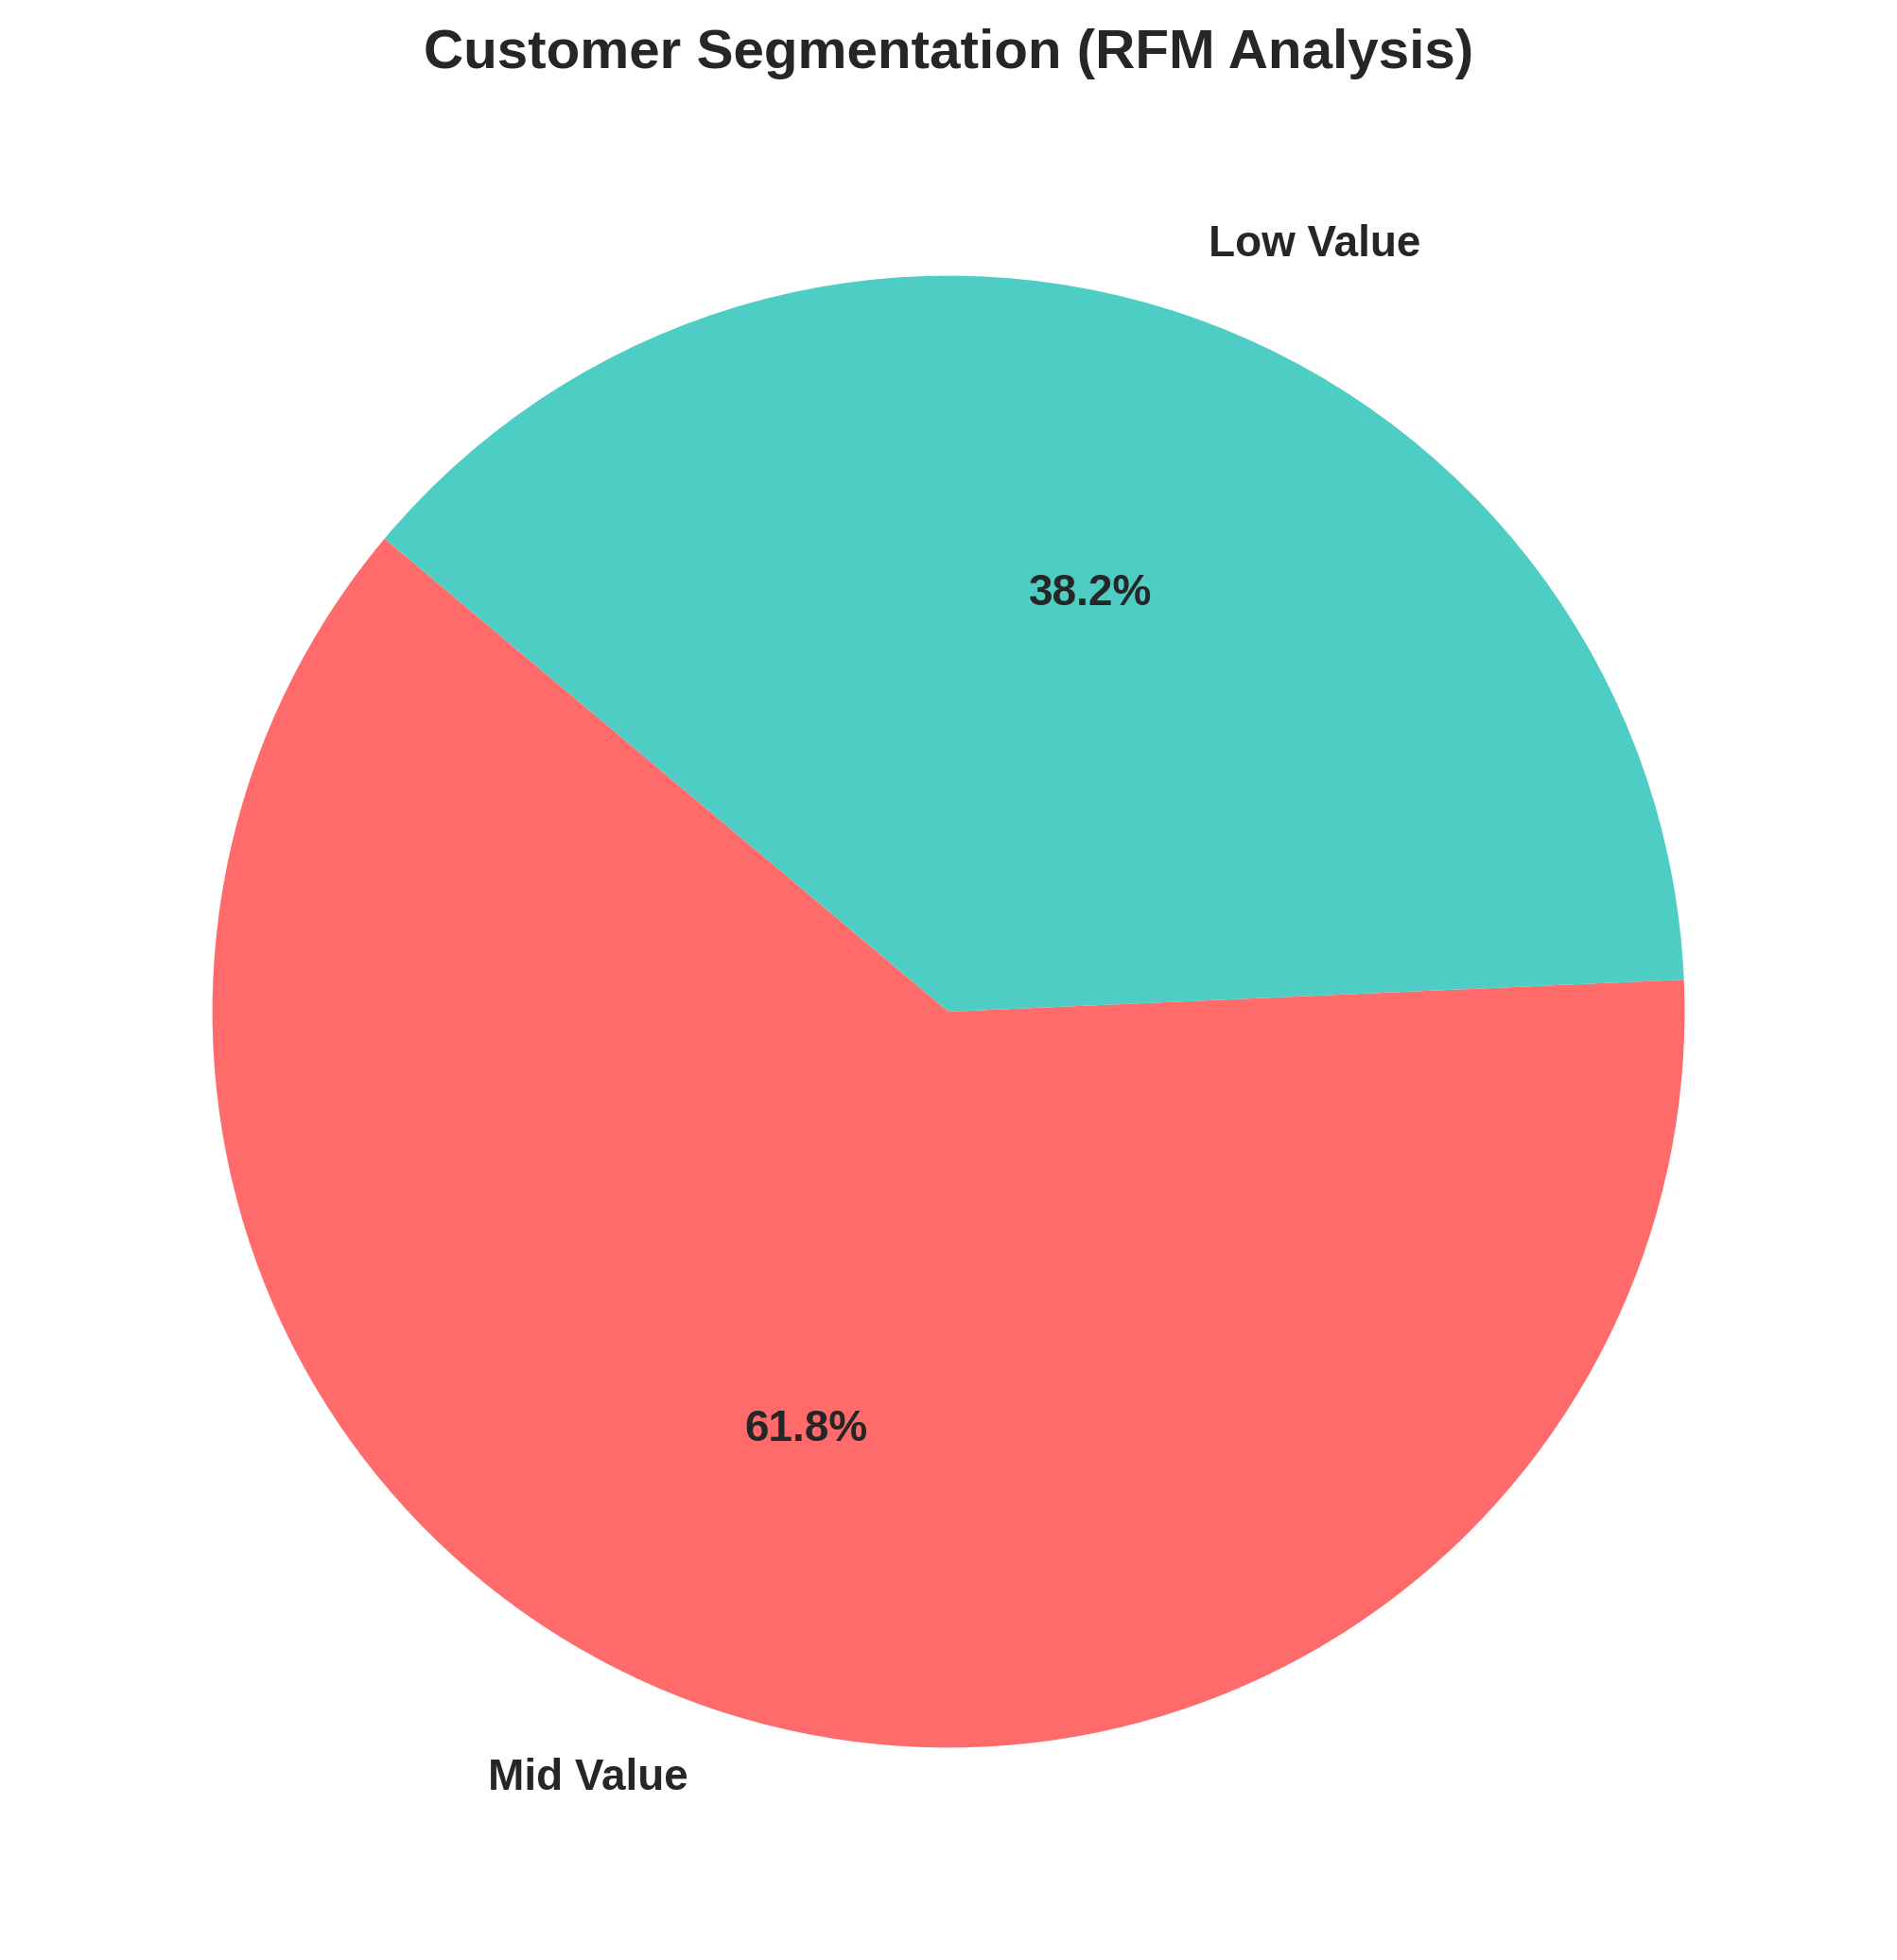

In [92]:
from IPython.display import Image, display
display(Image('/mnt/user-data/outputs/07_Customer_Segmentation.png'))

In [95]:
# ─────────────────────────────────────────────────────────
# SECTION 8: SUMMARY REPORT
# ─────────────────────────────────────────────────────────

print("\n" + "="*70)
print("ANALYSIS SUMMARY REPORT")
print("="*70)

print(f"""
╔════════════════════════════════════════════════════════════════════╗
║                    EXECUTIVE SUMMARY                              ║
╚════════════════════════════════════════════════════════════════════╝

📊 DATASET OVERVIEW:
   • Total Transactions      : {len(df):>10,}
   • Unique Customers        : {total_customers:>10,}
   • Analysis Period         : {df['Order_Date'].min().date()} to {df['Order_Date'].max().date()}
   • Product Categories      : {df['Category'].nunique():>10}
   • Geographic Regions      : {df['Region'].nunique():>10}

💰 FINANCIAL PERFORMANCE:
   • Total Revenue           : ${total_revenue:>18,.2f}
   • Total Profit            : ${total_profit:>18,.2f}
   • Profit Margin           : {profit_margin:>18.2f}%
   • Average Order Value     : ${avg_order_value:>17,.2f}

📈 GROWTH METRICS:
   • Revenue per Customer    : ${(total_revenue/total_customers):>16,.2f}
   • Average Profit per Order: ${(total_profit/total_orders):>17,.2f}
   • Orders per Customer     : {(total_orders/total_customers):>18.2f}

🎯 TOP PERFORMERS:
   • Top Category            : {category_stats.index[0]}
   • Top Region              : {region_stats.index[0]}
   • Top Product             : {top_products.index[0]}

👥 CUSTOMER INSIGHTS (RFM):
   • High Value Customers    : {len(rfm[rfm['Segment']=='High Value']):>10} ({len(rfm[rfm['Segment']=='High Value'])/len(rfm)*100:.1f}%)
   • Mid Value Customers     : {len(rfm[rfm['Segment']=='Mid Value']):>10} ({len(rfm[rfm['Segment']=='Mid Value'])/len(rfm)*100:.1f}%)
   • Low Value Customers     : {len(rfm[rfm['Segment']=='Low Value']):>10} ({len(rfm[rfm['Segment']=='Low Value'])/len(rfm)*100:.1f}%)
""")


ANALYSIS SUMMARY REPORT

╔════════════════════════════════════════════════════════════════════╗
║                    EXECUTIVE SUMMARY                              ║
╚════════════════════════════════════════════════════════════════════╝

📊 DATASET OVERVIEW:
   • Total Transactions      :      4,355
   • Unique Customers        :        987
   • Analysis Period         : 2022-01-01 to 2023-12-31
   • Product Categories      :          3
   • Geographic Regions      :          5

💰 FINANCIAL PERFORMANCE:
   • Total Revenue           : $     15,198,537.95
   • Total Profit            : $      3,331,496.32
   • Profit Margin           :              21.92%
   • Average Order Value     : $         3,489.91

📈 GROWTH METRICS:
   • Revenue per Customer    : $       15,398.72
   • Average Profit per Order: $           764.98
   • Orders per Customer     :               4.41

🎯 TOP PERFORMERS:
   • Top Category            : Accessories
   • Top Region              : South
   • Top Product     